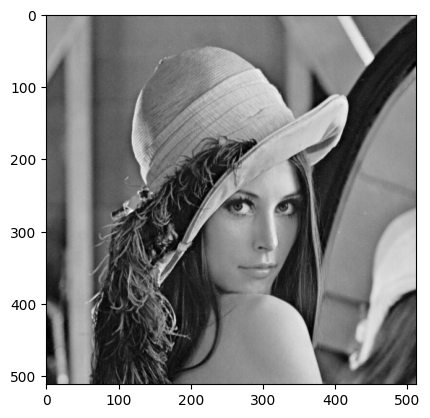

In [2]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("Lenna.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

# Part 1. 強度轉換
r:原向素值 s:輸出像素值

## linear
$s = ar + b$

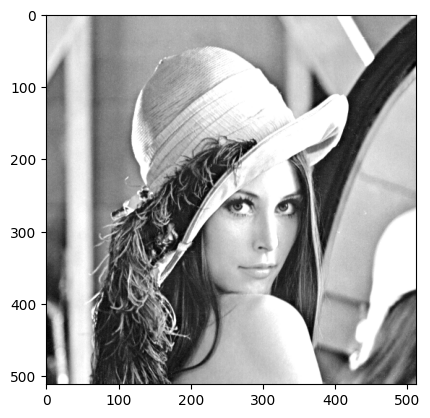

In [4]:
import numpy as np

alpha = 1.2 #對比度
beta = 30 #亮度
linear = alpha*img + beta
linear = np.clip(linear, 0, 255).astype(np.uint8)
plt.imshow(linear, cmap="gray")

## Log
$s = c \cdot log(1+r)$

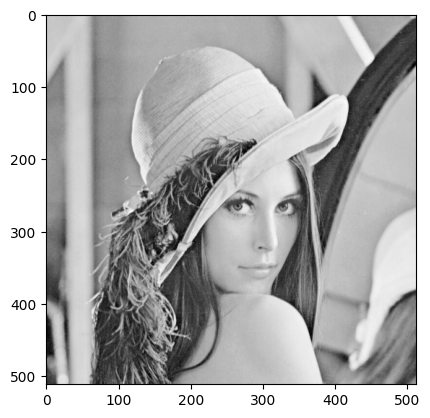

In [5]:
c = 255 / np.log(1 + np.max(img))
log_trans = c * np.log(1 + img)
log_trans = np.clip(log_trans, 0, 255).astype(np.uint8)
plt.imshow(log_trans, cmap="gray")

## gamma

$s = c \cdot r^\gamma$

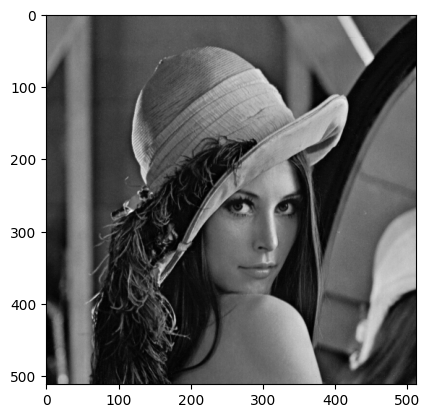

In [13]:
gamma = 1.8
c = 255 / (255 ** gamma)
gamma_corrected = c * (img ** gamma)
gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)
plt.imshow(gamma_corrected, cmap="gray")

# Part 2. 直方圖

###1. 繪圖

In [32]:
print(img[255, 10])

112


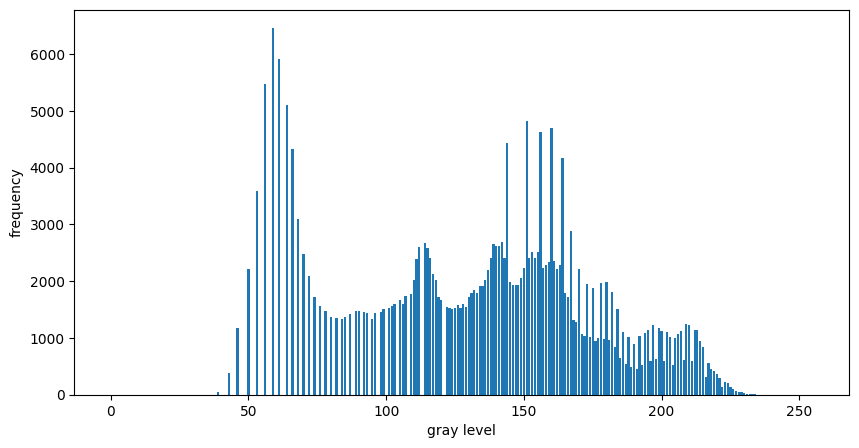

In [40]:
h, w = img.shape
hist = np.zeros(256, dtype=np.int32)
for i in range(h):
  for j in range(w):
    gray = img[i, j] #讀取該像素的灰階值
    hist[gray] += 1 #統計像素數量


plt.figure(figsize=(10, 5))
plt.bar(np.arange(256), hist)
plt.xlabel("gray level")
plt.ylabel("frequency")
plt.show()

### 2.均衡化

####$s = \mathrm{round}\left( \frac{(CDF(r) - CDF_{\min})}{(H \times W - CDF_{\min})}{}{(L - 1)} \right)$

In [41]:
cdf = np.cumsum(hist)
print(cdf)

[     0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0     45
     45     45     45    433    433    433   1604   1604   1604   1604
   3815   3815   3815   7398   7398   7398  12870  12870  12870  19330
  19330  25252  25252  25252  30356  30356  34681  34681  37781  37781
  40260  40260  42353  42353  44083  44083  45649  45649  47118  47118
  48495  48495  49840  49840  51175  52542  52542  53958  53958  55437
  56905  56905  58370  59808  59808  61136  62567  62567  64032  65536
  65536  67058  68622  70227  70227  71901  73505  75246  75246  77020
  79041  81439  84037  84037  86710  89298  91701  93827  95854  97584
  99260  99260 100814 102336 103846 105375 106954 108490 110093 111635
 113354 115149 117000 118796 120715 122631 124653 126851 129260 131910
 13453

In [42]:
print(np.nonzero(cdf))

(array([ 39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
       182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194,
       195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,
       208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 2

/tmp/ipython-input-2509160183.py:14: RuntimeWarning: overflow encountered in scalar add
  hist_eq[gray] += 1


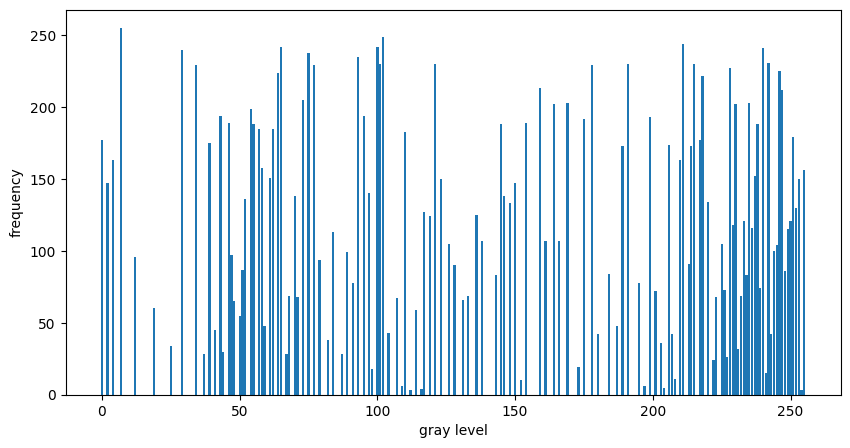

In [43]:
cdf = np.cumsum(hist)
cdf_min = cdf[np.nonzero(cdf)][0]
L = 256

equal_map = np.round((cdf - cdf_min)/(h*w - cdf_min) * (L - 1))
equal_map = equal_map.astype(np.uint8)

equalized = equal_map[img]

hist_eq = np.zeros(256, dtype=np.uint8)
for i in range(h):
  for j in range(w):
    gray = equalized[i, j]
    hist_eq[gray] += 1

plt.figure(figsize=(10, 5))
plt.bar(np.arange(256), hist_eq)
plt.xlabel("gray level")
plt.ylabel("frequency")
plt.show()

圖片對比

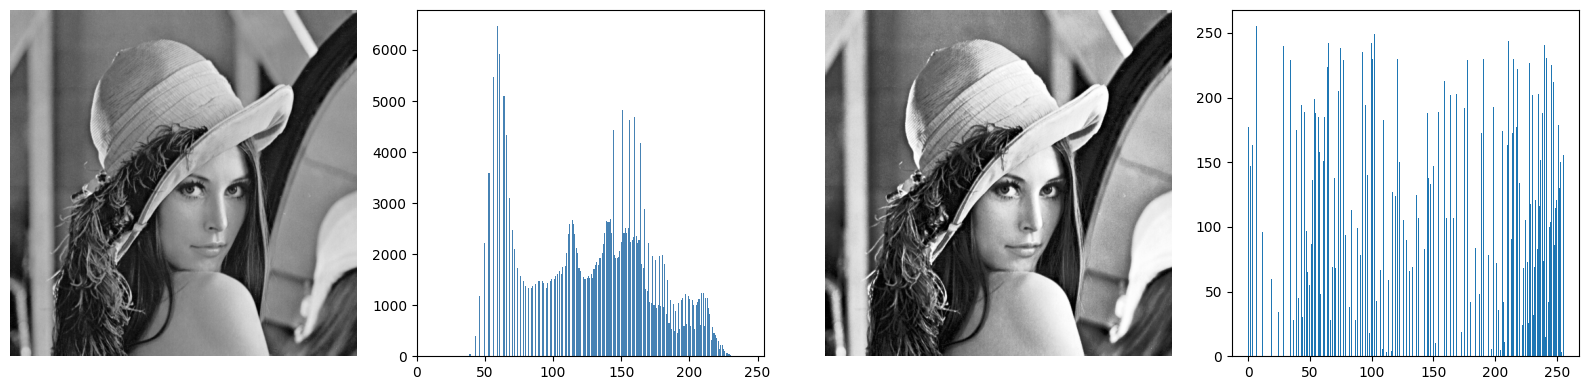

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))


axes[0].imshow(img, cmap="gray")
axes[0].axis("off")

axes[1].bar(np.arange(256), hist, color = "steelblue")
axes[1].set_xlim([0, 255])
axes[2].imshow(equalized, cmap="gray")
axes[2].axis("off")


axes[3].bar(np.arange(256), hist_eq)

plt.tight_layout()
plt.show()